# NotifyOps - Entrenamiento, comparacion y evidencia Parcial 3

Este notebook documenta la evolucion del pipeline ETL de Parcial 2. La extension de Parcial 3 incorpora calidad de datos, senales conductuales, comparacion de modelos, metricas, rendimiento, decisiones reglas + IA, seguridad y fuente BI.

## 1. Preparacion reproducible

Se usa la implementacion del repositorio para evitar que el notebook tenga una logica distinta al sistema ejecutable. La semilla fija permite obtener la misma particion y resultados.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

from src.notifyops_ai import modeling
from src.notifyops_ai import bi_dataset

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
result = modeling.run_ai_pipeline(seed=42, save_plots=True, write_outputs=True)
print("Fuente oficial:", result.performance["dataset_source"])
print("Filas totales:", result.performance["dataset_rows"])
print("Modelo seleccionado:", result.selected_model)
print("Filas de entrenamiento:", result.performance["train_rows"])
print("Filas de prueba:", result.performance["test_rows"])

Fuente oficial: social_events_200.xlsx
Filas totales: 200
Modelo seleccionado: random_forest
Filas de entrenamiento: 140
Filas de prueba: 60


## 2. Dataset y variable objetivo

La etiqueta `label_risky_event` combina errores estructurales con senales de comportamiento historico. Esto permite que la IA detecte riesgo incluso cuando un evento pasa las reglas duras.

In [2]:
events = pd.read_csv("data/ai/notifyops_ai_events.csv")
display(events.head())
display(events["label_risky_event"].value_counts().rename(index={0: "valido", 1: "riesgoso"}).to_frame("cantidad"))

,event_id,event_type,source_user_id,target_user_id,created_at,content,interaction_velocity_5m,account_age_days,historical_report_rate,is_duplicate,historical_feedback_risk,label_risky_event
0,evt-001,like,u107,u211,2026-06-01 08:03:17,NaN,14,42,0.17,0,0,0
1,evt-074,comment,u168,u204,2026-06-01 12:02:58,Gracias por compartir,18,1247,0.18,0,0,1
2,evt-147,follow,u139,u287,2026-06-01 16:02:39,NaN,22,956,0.19,0,0,0
3,evt-020,like,u150,u240,2026-06-01 09:05:40,NaN,36,745,0.30,0,1,1
4,evt-093,comment,u121,u233,2026-06-01 13:05:21,Me interesa,40,454,0.00,0,1,0


,cantidad
label_risky_event,
riesgoso,103
valido,97


## 3. Calidad, nulos e imputacion

Los nulos estructurales se conservan como indicadores explicitos. Las senales numericas se convierten a numero y, si falta un valor, se imputa con la mediana calculada en la preparacion.

In [3]:
quality = pd.read_csv("data/reports/ai/quality_summary.csv")
display(quality)
print("Estrategia:", quality.loc[quality["indicator"] == "imputation_strategy", "value"].iloc[0])

,indicator,value
0,rows,200
1,missing_source_user,1
2,missing_target_user,2
3,invalid_dates,2
4,duplicate_events,0
5,invalid_event_types,16
6,valid_events,97
7,risky_events,103
8,content_length_mean,6.26
9,content_length_median,0.0


Estrategia: mediana para senales numericas; indicadores explicitos para nulos estructurales


## 4. Analisis univariado y bivariado

El analisis univariado muestra la distribucion por tipo. El analisis bivariado compara el riesgo promedio entre tipos de evento. La matriz de correlacion permite observar relaciones entre variables y objetivo.

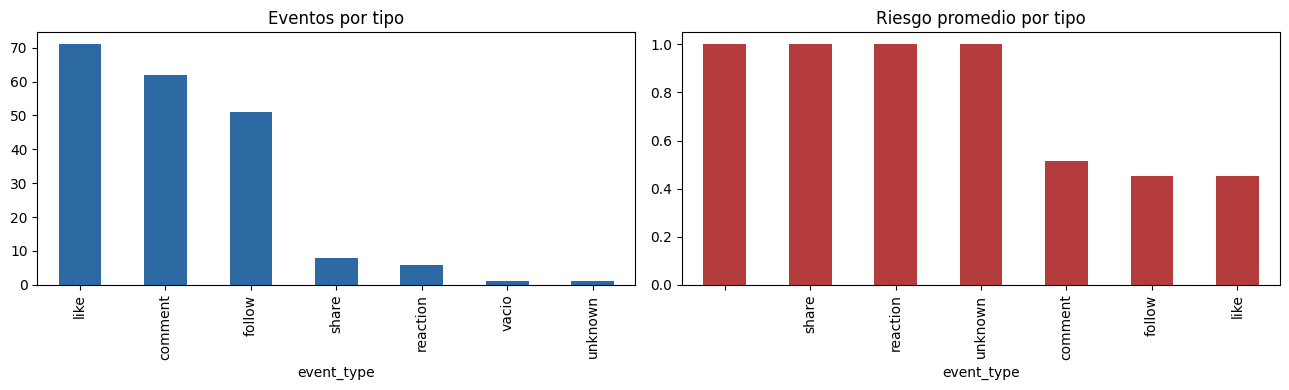

,content_length,hour,day_of_week,interaction_velocity_5m,account_age_days,historical_report_rate,is_duplicate,has_source_user,has_target_user,has_valid_date,is_allowed_event_type,event_type_like,event_type_comment,event_type_follow,event_type_invalid,label_risky_event
content_length,1.000,0.332,-0.048,-0.012,0.158,0.018,NaN,0.050,-0.138,-0.048,-0.628,-0.519,0.555,-0.410,0.628,0.243
hour,0.332,1.000,0.407,-0.016,0.072,0.006,NaN,-0.108,0.127,0.407,-0.438,-0.704,0.009,0.490,0.438,0.090
day_of_week,-0.048,0.407,1.000,-0.051,-0.154,0.028,NaN,-0.007,0.495,1.000,-0.030,0.075,-0.041,-0.056,0.030,-0.098
interaction_velocity_5m,-0.012,-0.016,-0.051,1.000,0.041,-0.031,NaN,-0.104,-0.000,-0.051,0.034,0.005,0.026,-0.012,-0.034,0.338
account_age_days,0.158,0.072,-0.154,0.041,1.000,0.003,NaN,-0.093,-0.150,-0.154,-0.172,-0.104,0.047,-0.043,0.172,0.153
historical_report_rate,0.018,0.006,0.028,-0.031,0.003,1.000,NaN,0.111,-0.051,0.028,-0.013,-0.019,0.003,0.008,0.013,0.537
is_duplicate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_source_user,0.050,-0.108,-0.007,-0.104,-0.093,0.111,NaN,1.000,-0.007,-0.007,-0.021,-0.096,0.048,0.041,0.021,-0.069
has_target_user,-0.138,0.127,0.495,-0.000,-0.150,-0.051,NaN,-0.007,1.000,0.495,-0.030,0.075,-0.150,0.059,0.030,-0.098
has_valid_date,-0.048,0.407,1.000,-0.051,-0.154,0.028,NaN,-0.007,0.495,1.000,-0.030,0.075,-0.041,-0.056,0.030,-0.098


In [4]:
engineered = modeling.engineer_features(events)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
engineered["event_type"].replace("", "vacio").value_counts().plot(kind="bar", ax=axes[0], color="#2d6aa3", title="Eventos por tipo")
engineered.groupby("event_type")["label_risky_event"].mean().sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="#b43c3c", title="Riesgo promedio por tipo")
plt.tight_layout()
plt.show()
display(pd.read_csv("data/reports/ai/correlation_matrix.csv", index_col=0).round(3))

## 5. Particion y comparacion de modelos

Todos los candidatos usan la misma particion estratificada 70/30. Se comparan un baseline de clase mayoritaria, regresion logistica y Random Forest. La seleccion prioriza F1 y conserva regresion logistica cuando queda a 0,03 o menos del mejor F1 por su mayor interpretabilidad.

,model,accuracy,precision,recall,f1_score,roc_auc,gini,training_seconds,inference_seconds,selected
0,baseline_clase_mayoritaria,0.5167,0.5167,1.0000,0.6813,0.5000,0.0000,0.000086,0.000010,0
1,regresion_logistica,0.8833,0.9286,0.8387,0.8814,0.9711,0.9422,0.119780,0.000072,0
2,random_forest,0.9500,0.9118,1.0000,0.9538,0.9967,0.9933,0.421250,0.029080,1


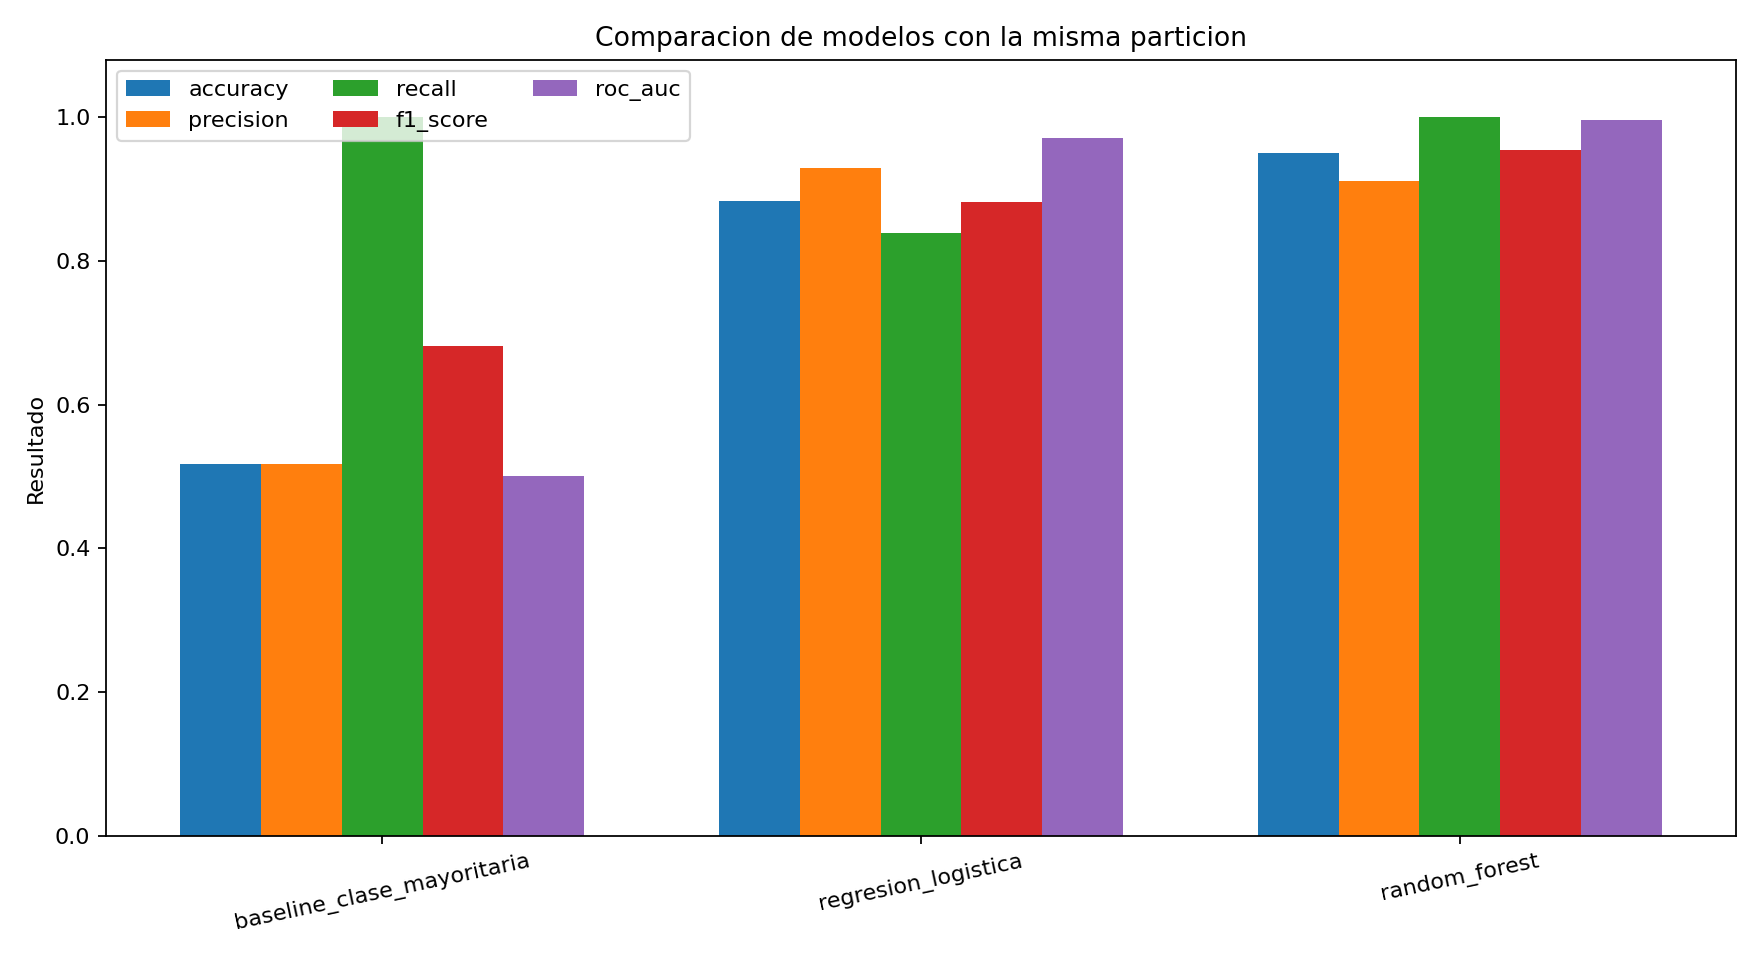

In [5]:
comparison = pd.read_csv("data/reports/ai/model_comparison.csv")
display(comparison[["model", "accuracy", "precision", "recall", "f1_score", "roc_auc", "gini", "training_seconds", "inference_seconds", "selected"]])
Image(filename="data/reports/ai/charts/model_comparison.png")

## 6. Metricas del modelo seleccionado

- Accuracy: proporcion total de aciertos.
- Precision: de los eventos marcados riesgosos, cuantos realmente lo eran.
- Recall: de los eventos riesgosos reales, cuantos fueron detectados.
- F1: equilibrio entre precision y recall.
- ROC-AUC: capacidad de ordenar riesgosos por encima de validos.
- Gini: transformacion `2 * AUC - 1`.

,valor
accuracy,0.9500
precision,0.9118
recall,1.0000
f1_score,0.9538
roc_auc,0.9967
gini,0.9933
threshold,0.5000
true_negatives_valid_detected,26.0000
false_positives_valid_marked_risky,3.0000
false_negatives_risky_marked_valid,0.0000


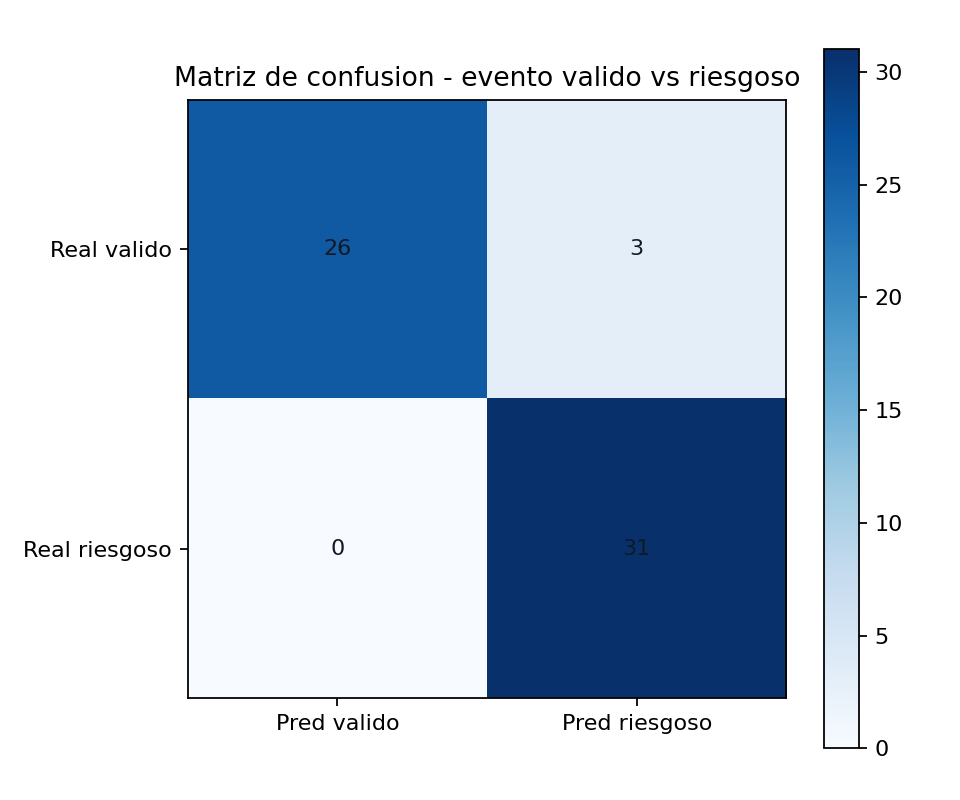

In [6]:
metrics = pd.read_csv("data/reports/ai/model_metrics.csv")
display(metrics.T.rename(columns={0: "valor"}))
Image(filename="data/reports/ai/charts/confusion_matrix.png")

## 7. Curva ROC y rendimiento local

La curva ROC se guarda tanto como imagen como puntos tabulares para Power BI. Los tiempos corresponden a mediciones locales reales de entrenamiento e inferencia.

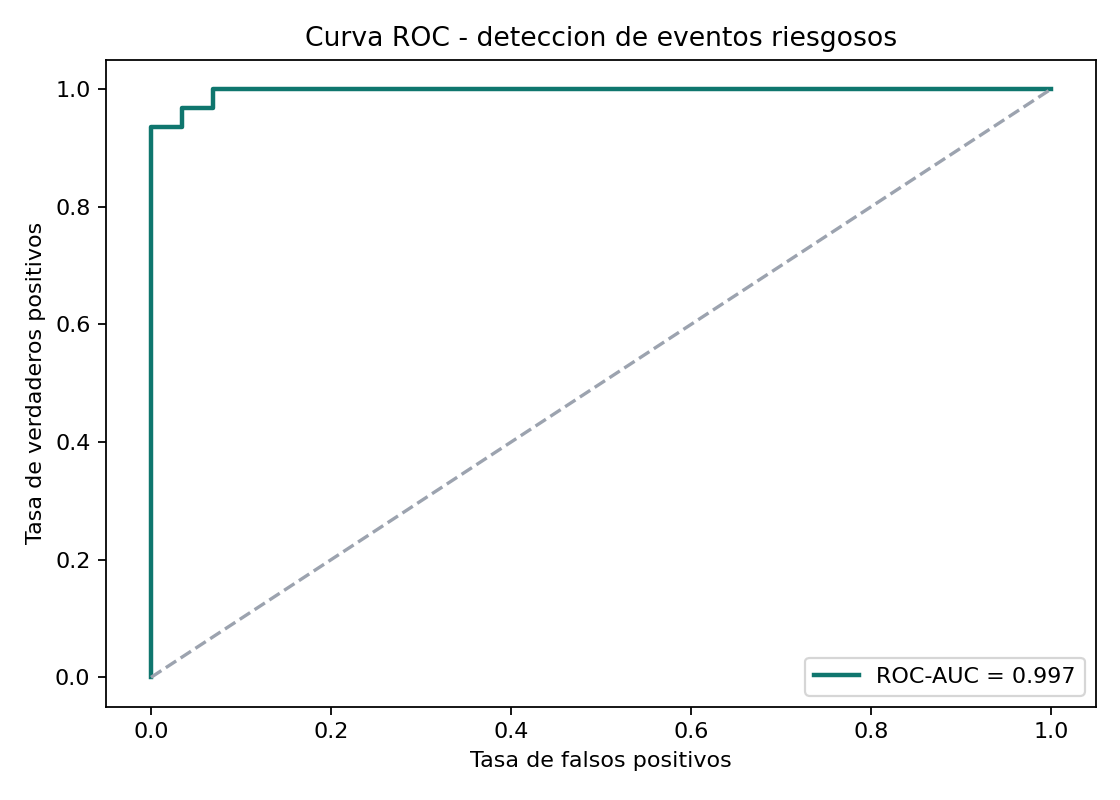

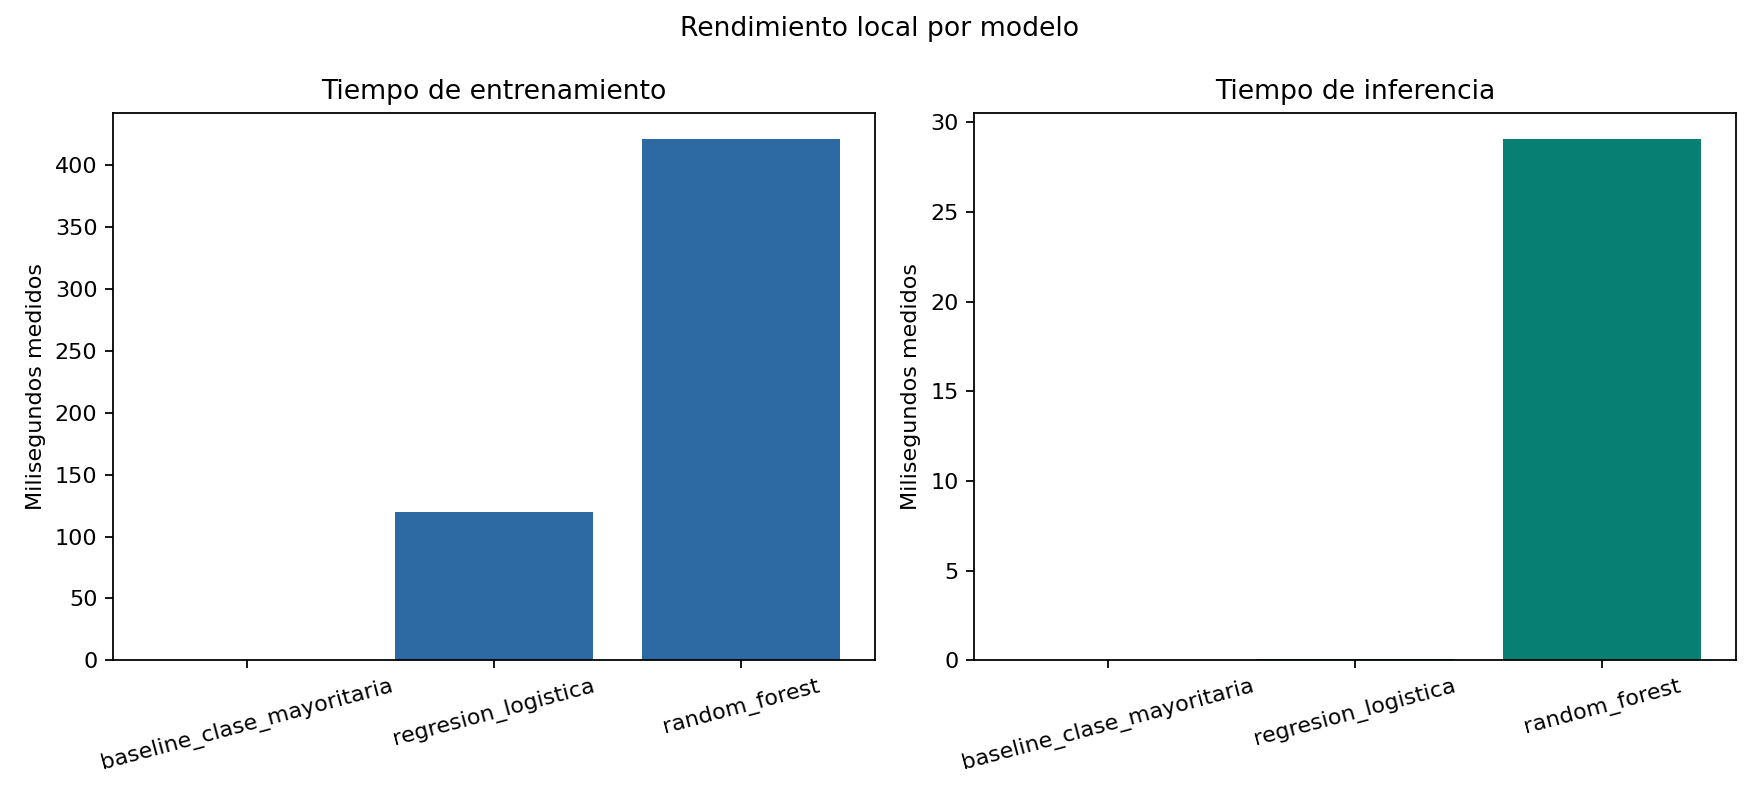

,training_seconds,inference_seconds,inference_rows,inference_rows_per_second,dataset_rows,dataset_source,train_rows,test_rows
0,0.42125,0.02908,60,2063.27,200,social_events_200.xlsx,140,60


In [7]:
display(Image(filename="data/reports/ai/charts/roc_curve.png"))
display(Image(filename="data/reports/ai/charts/runtime_comparison.png"))
display(pd.read_csv("data/reports/ai/performance_summary.csv"))

## 8. Decision operacional integrada

Las reglas duras mantienen el control de errores objetivos. La IA solo interviene cuando el evento pasa reglas, produciendo `revision_por_ia` si el riesgo es alto.

In [8]:
decisions = pd.read_csv("data/reports/ai/final_event_decisions.csv")
display(decisions["final_decision"].value_counts().to_frame("cantidad"))
display(decisions.loc[decisions["final_decision"] == "revision_por_ia", ["event_id", "event_type", "ai_risk_probability", "final_decision"]].head(10))

,cantidad
final_decision,
aprobado_para_notificar,93
revision_por_ia,87
rechazado_por_reglas,20


,event_id,event_type,ai_risk_probability,final_decision
1,evt-074,comment,0.6277,revision_por_ia
3,evt-020,like,0.8754,revision_por_ia
4,evt-093,comment,0.6078,revision_por_ia
5,evt-166,follow,0.6354,revision_por_ia
9,evt-058,like,0.8856,revision_por_ia
10,evt-131,follow,0.9058,revision_por_ia
16,evt-169,follow,0.7830,revision_por_ia
22,evt-007,like,0.7377,revision_por_ia
23,evt-080,comment,0.7981,revision_por_ia
24,evt-153,follow,0.8381,revision_por_ia


## 9. Seguridad, roles y normativa

La fuente BI excluye contenido textual y reemplaza identificadores de usuario por claves seudonimizadas. La estrategia se vincula con minimizacion, finalidad, acceso limitado y seguridad de la Ley 19.628. Tambien se reconoce la transicion hacia la Ley 21.719, cuya vigencia inicia el 1 de diciembre de 2026.

In [9]:
display(bi_dataset._security_audit())
display(bi_dataset._roles())

,asset,sensitivity,risk,implemented_control,recommended_control,authorized_roles,legal_alignment
0,event_id,baja,reutilizacion del identificador tecnico,identificador tecnico sin datos personales dir...,rotacion o tokenizacion si se integra con sist...,"DataOps, Analista BI, Auditor",finalidad y minimizacion
1,source_user_id,media,asociacion de actividad a una persona usuaria,seudonimizacion SHA-256 antes de exportar a BI,separar tabla de correspondencias y limitar su...,Administrador DataOps,Ley 19.628: acceso limitado y uso proporcional
2,target_user_id,media,inferencia de relaciones entre usuarios,seudonimizacion y visualizacion agregada,aplicar retencion limitada y auditoria de acceso,Administrador DataOps,Ley 19.628: seguridad y finalidad
3,content,alta,texto libre con posibles datos personales o se...,contenido excluido del dataset BI,cifrado y acceso excepcional en una implementa...,Auditor autorizado con justificacion,minimizacion y tratamiento limitado
4,created_at,media,perfilamiento temporal de actividad,uso operacional y filtros; no identifica por s...,agregacion temporal para reportes publicos,"DataOps, Analista BI, Auditor",proporcionalidad
5,logs,media,"exposicion de rutas, errores o trazas tecnicas",logs sin contrasenas ni contenido de usuarios,"rotacion, retencion y acceso por rol","Administrador DataOps, Auditor",seguridad del tratamiento
6,model_metrics,baja,interpretacion incorrecta del rendimiento,"versionamiento junto con fecha, particion y mo...",monitoreo de drift y recalibracion,"Equipo, Profesor, Analista BI",sin dato personal directo


,role,allowed_access,restriction
0,Administrador DataOps,"pipeline, logs, datos tecnicos, modelo y confi...",no publicar datos identificables sin necesidad
1,Analista BI,"metricas, agregados, claves seudonimizadas y d...",sin ids originales ni contenido textual
2,Auditor/Profesor,"evidencias, metricas, codigo, informe y dashboard",uso academico y revision tecnica
3,Usuario de negocio,indicadores agregados y decisiones operacionales,sin datos individuales ni configuracion del mo...


## 10. Integracion BI y evidencias

El Excel se genera desde los CSV de esta ejecucion. El dashboard local consume un JSON sin identificadores personales y ofrece filtros por evento y decision.

In [10]:
workbook_path = bi_dataset.build_powerbi_workbook()
print("Excel BI:", workbook_path)
print("Dashboard:", Path("dashboard/notifyops_ai_dashboard.html").resolve())
print("Datos dashboard:", Path("dashboard/data/dashboard_data.json").resolve())

Excel BI: C:\Users\Vivobook Pro 15\Downloads\Geiaproyecot\ENTREGA_LISTA_NOTIFYOPS\data\bi\notifyops_powerbi_dataset.xlsx
Dashboard: C:\Users\Vivobook Pro 15\Downloads\Geiaproyecot\ENTREGA_LISTA_NOTIFYOPS\dashboard\notifyops_ai_dashboard.html
Datos dashboard: C:\Users\Vivobook Pro 15\Downloads\Geiaproyecot\ENTREGA_LISTA_NOTIFYOPS\dashboard\data\dashboard_data.json


## 11. Limitaciones y conclusion

La muestra oficial contiene 200 eventos academicos versionados en `data/raw/social_events_200.xlsx`. No representa toda la variabilidad productiva y el entorno evaluado es local/Docker, no nube productiva. La latencia operacional del MVP es simulada; los tiempos de ETL, entrenamiento e inferencia si son mediciones reales. El resultado demuestra una mejora trazable: la misma fuente alimenta ETL e IA, las reglas obligatorias conservan prioridad y los resultados se publican de forma consistente para BI, informe y presentacion.
